# SARAH-3 (SIS) Preprocessing – Eindhoven (0.05° grid)

**Goal**

Turn the large SARAH-3 daily SIS dataset (full Meteosat disk, 0.05°) into:

1. Small daily NetCDF files for the Eindhoven box (51–52°N, 5–6°E).
2. Optionally: one combined time-series file that is easy to use for
   analysis and validation with NASA POWER + CAMS.

**Input**

- TAR from CM SAF already downloaded and extracted.
- Extracted daily NetCDF files placed in  
  `data/SARAH3/raw/`

**Output**

- Subsetted daily files → `data/SARAH3/eindhoven_0.05/`
- Optional merged file → `data/SARAH3/sarah3_sis_eindhoven_0.05_2024-01-01_2025-04-01.nc`

## 1. Imports & folder setup

In [2]:
from pathlib import Path
import xarray as xr
import pandas as pd

# Base data folder for this project (adapt if needed)
BASE_DIR = Path("data")

# SARAH folders
SARAH_RAW_DIR   = BASE_DIR / "SARAH3" / "raw"             # 457 daily files here
SARAH_OUT_DIR   = BASE_DIR / "SARAH3" / "eindhoven_0.05"  # subsetted daily files
SARAH_OUT_DIR.mkdir(parents=True, exist_ok=True)

SARAH_MERGED_FILE = BASE_DIR / "SARAH3" / "sarah3_sis_eindhoven_0.05_2024-01-01_2025-04-01.nc"

print("RAW folder:   ", SARAH_RAW_DIR.resolve())
print("OUTPUT folder:", SARAH_OUT_DIR.resolve())
print("Merged file:  ", SARAH_MERGED_FILE.resolve())


RAW folder:    C:\Users\Student\Desktop\SIS\data\SARAH3\raw
OUTPUT folder: C:\Users\Student\Desktop\SIS\data\SARAH3\eindhoven_0.05
Merged file:   C:\Users\Student\Desktop\SIS\data\SARAH3\sarah3_sis_eindhoven_0.05_2024-01-01_2025-04-01.nc


## 2. Quick inventory & sanity check

We first check:
- How many NetCDF files are in `SARAH3/raw`
- Open one file to see:
  - Coordinate names (usually lat, lon, time)
  - Main variable name (usually SIS)

In [3]:
# List all SARAH raw files
raw_files = sorted(SARAH_RAW_DIR.glob("*.nc"))
print(f"Found {len(raw_files)} raw SARAH files.")

# Inspect one sample file (first one)
if not raw_files:
    raise FileNotFoundError("No NetCDF files found in SARAH3/raw. "
                            "Make sure you extracted the TAR into this folder.")

sample_file = raw_files[0]
print("Sample file:", sample_file.name)

sample_ds = xr.open_dataset(sample_file)
print(sample_ds)
print("\nData variables:", list(sample_ds.data_vars))
print("Coordinates:", list(sample_ds.coords))

sample_ds.close()

Found 457 raw SARAH files.
Sample file: SISdm2024010100000042310001I1MA.nc
<xarray.Dataset> Size: 54MB
Dimensions:        (time: 1, bnds: 2, lon: 2600, lat: 2600)
Coordinates:
  * time           (time) datetime64[ns] 8B 2024-01-01
  * lon            (lon) float32 10kB -64.97 -64.93 -64.88 ... 64.88 64.93 64.97
  * lat            (lat) float32 10kB -64.97 -64.93 -64.88 ... 64.88 64.93 64.97
Dimensions without coordinates: bnds
Data variables:
    time_bnds      (time, bnds) datetime64[ns] 16B ...
    lon_bnds       (lon, bnds) float32 21kB ...
    lat_bnds       (lat, bnds) float32 21kB ...
    SIS            (time, lat, lon) float32 27MB ...
    SISC           (time, lat, lon) float32 27MB ...
    record_status  (time) int8 1B ...
Attributes: (12/39)
    institution:                EUMETSAT/CMSAF
    Conventions:                CF-1.7,ACDD-1.3
    title:                      CM SAF Surface Solar Radiation Climate Data R...
    summary:                    This file contains data from th

## 3. Helper: detect coordinate names and handle latitude direction

CM SAF sometimes uses lat/lon, sometimes latitude/longitude.

We will:

1. Detect the correct coordinate names.
2. Handle the case where latitude is descending (from north to south).
3. Subset to the Eindhoven box:

- Latitude: 51°N to 52°N  
- Longitude: 5°E to 6°E

In [4]:
def get_coord_names(ds: xr.Dataset):
    """Return (lat_name, lon_name) used in the Dataset."""
    if "lat" in ds.coords:
        lat_name = "lat"
    elif "latitude" in ds.coords:
        lat_name = "latitude"
    else:
        raise KeyError("Could not find latitude coordinate in dataset.")

    if "lon" in ds.coords:
        lon_name = "lon"
    elif "longitude" in ds.coords:
        lon_name = "longitude"
    else:
        raise KeyError("Could not find longitude coordinate in dataset.")

    return lat_name, lon_name


def subset_eindhoven(ds: xr.Dataset) -> xr.Dataset:
    """
    Subset SARAH dataset to Eindhoven box:
    lat: 51–52 N, lon: 5–6 E.
    Works for both ascending and descending latitude.
    """
    lat_name, lon_name = get_coord_names(ds)

    lats = ds[lat_name]
    lons = ds[lon_name]

    # Latitude can be ascending or descending
    lat_ascending = bool(lats[0] < lats[-1])

    if lat_ascending:
        lat_slice = slice(51.0, 52.0)
    else:
        lat_slice = slice(52.0, 51.0)

    lon_ascending = bool(lons[0] < lons[-1])

    if lon_ascending:
        lon_slice = slice(5.0, 6.0)
    else:
        lon_slice = slice(6.0, 5.0)

    ds_sub = ds.sel({lat_name: lat_slice, lon_name: lon_slice})

    return ds_sub


## 4. Process a single SARAH file

Function to:

1. Open one raw file.
2. Subset to Eindhoven.
3. Save subset as a new file under eindhoven_0.05.

This keeps the original time + SIS fields but with a tiny spatial window.


In [5]:
def process_sarah_file(in_path: Path, out_dir: Path) -> Path:
    """
    Subset one SARAH file to Eindhoven box and save it.

    Returns the output file path.
    """
    # Use same file name in the output folder
    out_path = out_dir / in_path.name

    # Skip if already processed
    if out_path.exists():
        return out_path

    ds = xr.open_dataset(in_path)

    # Subset to Eindhoven
    ds_sub = subset_eindhoven(ds)

    # Optionally ensure we only keep the SIS variable.
    # Comment this out if you want all variables.
    if "SIS" in ds_sub.data_vars:
        ds_sub = ds_sub[["SIS"]]

    # Preserve attributes
    ds_sub.to_netcdf(out_path)
    ds.close()
    ds_sub.close()

    return out_path


## 5. Loop over all SARAH files

Now we:

- Run process_sarah_file for every raw file.
- Keep a small log of successes.


In [6]:
from tqdm import tqdm  # if you don't have it: pip install tqdm

processed_paths = []

for f in tqdm(raw_files, desc="Processing SARAH files"):
    try:
        out_path = process_sarah_file(f, SARAH_OUT_DIR)
        processed_paths.append(out_path)
    except Exception as e:
        print(f"⚠ Error processing {f.name}: {e}")

print(f"\nDone. Subsetted {len(processed_paths)} files to {SARAH_OUT_DIR}.")


Processing SARAH files: 100%|████████████████████████████████████████████████████████| 457/457 [00:38<00:00, 11.82it/s]


Done. Subsetted 457 files to data\SARAH3\eindhoven_0.05.


## 6. Quick check of one subset file

Make sure the subset:

- Has only a small number of pixels (few lat/lon values).
- Time dimension looks correct.
- The SIS values are in a reasonable range (e.g., 0–30 kWh/m²/day).

In [8]:
subset_files = sorted(SARAH_OUT_DIR.glob("*.nc"))
print(f"Subset files found: {len(subset_files)}")

if subset_files:
    test_ds = xr.open_dataset(subset_files[0])
    print(test_ds)

    var_name = "SIS" if "SIS" in test_ds.data_vars else list(test_ds.data_vars)[0]
    print("\nUsing variable:", var_name)
    print("Min:", float(test_ds[var_name].min()))
    print("Max:", float(test_ds[var_name].max()))
    print("Mean:", float(test_ds[var_name].mean()))

    test_ds.close()

Subset files found: 457
<xarray.Dataset> Size: 2kB
Dimensions:  (time: 1, lat: 20, lon: 20)
Coordinates:
  * time     (time) datetime64[ns] 8B 2024-01-01
  * lon      (lon) float32 80B 5.025 5.075 5.125 5.175 ... 5.875 5.925 5.975
  * lat      (lat) float32 80B 51.03 51.08 51.12 51.17 ... 51.88 51.92 51.97
Data variables:
    SIS      (time, lat, lon) float32 2kB ...
Attributes: (12/39)
    institution:                EUMETSAT/CMSAF
    Conventions:                CF-1.7,ACDD-1.3
    title:                      CM SAF Surface Solar Radiation Climate Data R...
    summary:                    This file contains data from the CM SAF Surfa...
    id:                         DOI:10.5676/EUM_SAF_CM/SARAH/V003
    product_version:            3.0
    ...                         ...
    platform:                   Earth Observation Satellites > METEOSAT > MET...
    CMSAF_repeat_cycles:        METEOSAT-10=48
    instrument_vocabulary:      GCMD Instruments, Version 8.6
    instrument:          

## 7. Merging all subsetted SARAH-3 files

import xarray as xr
from pathlib import Path

subset_files = sorted(SARAH_OUT_DIR.glob("*.nc"))
print("Subset files:", len(subset_files))

if not subset_files:
    raise FileNotFoundError("No subset files found. Run Section 6 first.")

# Merge using Xarray (concatenate along time)
ds_merged = xr.open_mfdataset(
    subset_files,
    combine="nested",
    concat_dim="time",
    parallel=True
)

# Save to disk
ds_merged.to_netcdf(SARAH_MERGED_FILE)
print("Merged dataset saved to:", SARAH_MERGED_FILE)

ds_merged

## 8. Visualizing SARAH-3 SIS for Eindhoven

### 8.1 Daily mean SIS over Eindhoven

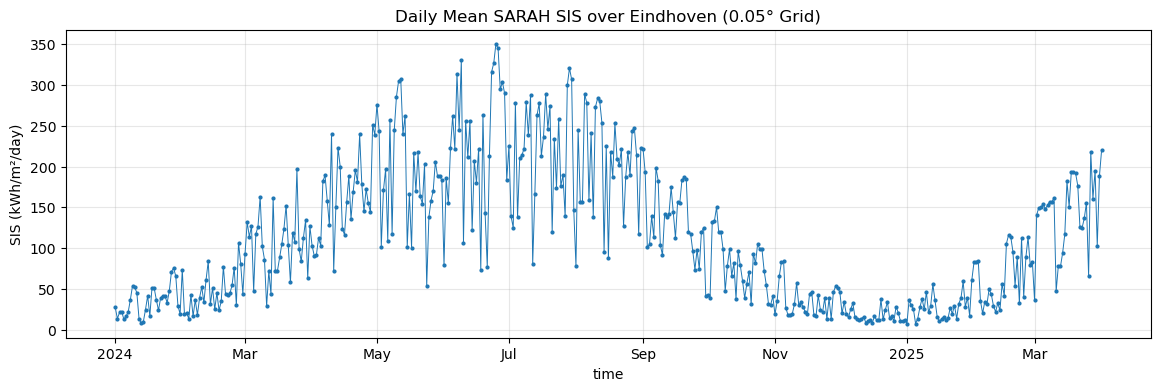

In [10]:
import matplotlib.pyplot as plt

# Load merged dataset
ds = xr.open_dataset(SARAH_MERGED_FILE)

var = "SIS"

# Mean over spatial grid
sis_mean_ts = ds[var].mean(dim=("lat", "lon"))

plt.figure(figsize=(14,4))
sis_mean_ts.plot(marker="o", markersize=2, linewidth=0.7)
plt.title("Daily Mean SARAH SIS over Eindhoven (0.05° Grid)")
plt.ylabel("SIS (kWh/m²/day)")
plt.grid(True, alpha=0.3)
plt.show()

The daily SIS mean curve shows a strong and expected seasonal pattern:
- Winter months (Dec–Feb): Radiation is very low (10–50 kWh/m²/day), with high day-to-day variability due to clouds.
- Spring (Mar–May): Rapid increase in radiation, with occasional dips on cloudy days.
- Summer peak (Jun–Aug): Highest values (~300–350 kWh/m²/day). The curve shows short-term drops caused by passing cloud systems.
- Autumn (Sep–Nov): Gradual decline toward winter levels.

This strong seasonality confirms the SARAH dataset is behaving correctly and aligns with the solar geometry at this latitude (~51°N).

### 8.2 Inspecting the spatial pattern of a single day

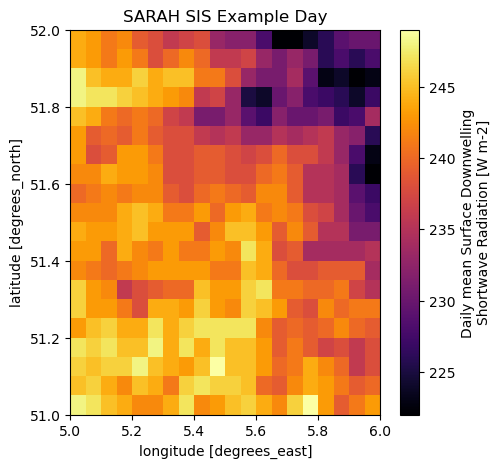

In [11]:
example_day = ds[var].isel(time=100)

plt.figure(figsize=(5,5))
example_day.plot(cmap="inferno")
plt.title("SARAH SIS Example Day")
plt.show()

The example day provides insight into the spatial structure inside the Eindhoven grid:
- The map is not uniform, meaning SARAH captures small-scale variations due to cloud cover differences, surface-atmosphere interactions, subtle terrain effects.
- The grid is coarse (20×20) but patterns still appear, such as slightly lower radiation toward the northeast on the example day.
- This is important because it shows why using spatial features (not just a single point value) could help the model learn local variability.

### 8.3 Monthly mean radiation maps

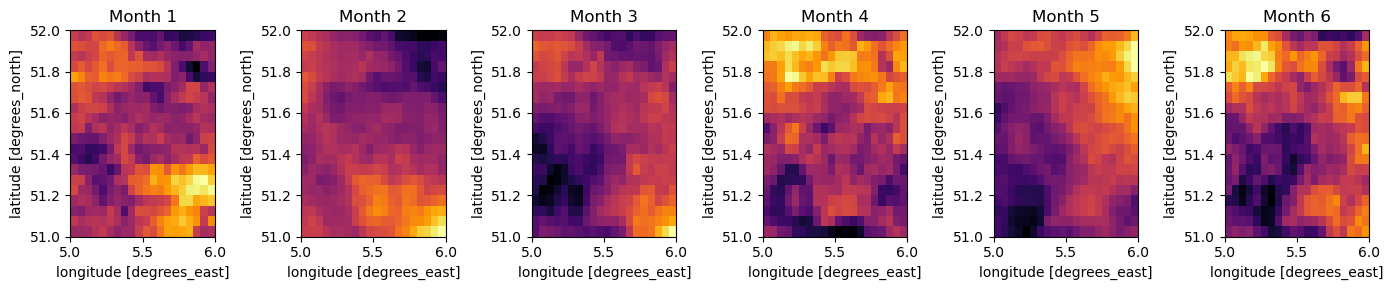

In [16]:
monthly_mean = ds[var].groupby("time.month").mean()

plt.figure(figsize=(14,3))
for i in range(6):  # First six months
    plt.subplot(1,6,i+1)
    monthly_mean.isel(month=i).plot(cmap="inferno", add_colorbar=False)
    plt.title(f"Month {i+1}")
plt.tight_layout()
plt.show()

- January-February: Radiation is uniformly low, with no strong spatial gradient—consistent with winter cloudiness.
- March-April: Radiation increases and becomes more spatially structured, especially showing higher values toward the south.
This makes sense because the sun angle increases and cloud formation is more variable.
- May-June: Highest spatial contrast—some areas (south/southeast) receive consistently more radiation.
This may reflect cloud climatology rather than terrain (which is flat in Eindhoven).

These results indicate that monthly SARAH composites can serve as stable features for model (as predictors or for comparison with Sentinel-2-derived features).

## 9. Conclusion

In this notebook we turned the full-disk SARAH-3 daily surface solar radiation (SIS) product into a compact, Eindhoven-focused dataset that is ready for analysis and model input. Starting from 457 raw daily NetCDF files in `SARAH3/raw`, we first confirmed the structure of the data: a global 0.05° latitude–longitude grid, a single time step per file and SIS as the main radiation variable. Using a small helper function, we then subset each file to the Eindhoven bounding box (51–52°N, 5–6°E), keeping only the SIS field and saving the result as much smaller daily NetCDF files in `SARAH3/eindhoven_0.05/`.

After checking one subset file (correct time stamp, 20×20 grid, reasonable SIS values), we merged all daily subsets into a single time-series file:
`data/SARAH3/sarah3_sis_eindhoven_0.05_2024-01-01_2025-04-01.nc`. This merged dataset provides a continuous record of daily surface solar radiation over Eindhoven on the SARAH 0.05° grid. The time series of spatially averaged SIS shows a clear seasonal cycle: low values and strong day-to-day variability in winter, rising through spring, a pronounced summer peak and a gradual decline into autumn. The example daily map and monthly composites confirm that SARAH also captures realistic spatial patterns inside the Eindhoven box, even on this relatively coarse grid. Together, this means future notebooks can directly load this merged SARAH file to combine with CAMS and DEM features and use it as a core target or predictor for solar radiation modelling, without repeating any preprocessing steps.